# Linear Regression

In [1]:
'''
Straight Line
---------------
y = mX + C

y -> Predicted Records
m -> Slope (Change)
X -> Data Points
C -> Intercept (Constant)

Metrics
-----------
- Target Test Data (X-Axis) and Model Predicted Data (Y-Axis)

- MAE (Mean Absolute Error)
    - Sum of distance between best fit line and data points.

- MSE (Mean Squared Error)
    - Sum of square distance between best fit line and data points.

- RMSE (Root Mean Squared Error)
    - Square root of MSE

- R2 Score (Resudial Score)

- If RMSE decreases R2 Score Increases (Correct)
- If RMSE increases R2 Score Decreases

- Linear Regression is sensitive to outliers.

'''

'\nStraight Line\n---------------\ny = mX + C\n\ny -> Predicted Records\nm -> Slope (Change)\nX -> Data Points\nC -> Intercept (Constant)\n\nMetrics\n-----------\n- Target Test Data (X-Axis) and Model Predicted Data (Y-Axis)\n\n- MAE (Mean Absolute Error)\n    - Sum of distance between best fit line and data points.\n\n- MSE (Mean Squared Error)\n    - Sum of square distance between best fit line and data points.\n\n- RMSE (Root Mean Squared Error)\n    - Square root of MSE\n\n- R2 Score (Resudial Score)\n\n- If RMSE decreases R2 Score Increases (Correct)\n- If RMSE increases R2 Score Decreases\n\n- Linear Regression is sensitive to outliers.\n\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import model
from sklearn.linear_model import LinearRegression
# to split feature and target data
from sklearn.model_selection import train_test_split
# for scaling of data
from sklearn.preprocessing import StandardScaler
# Import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='str')

<Axes: >

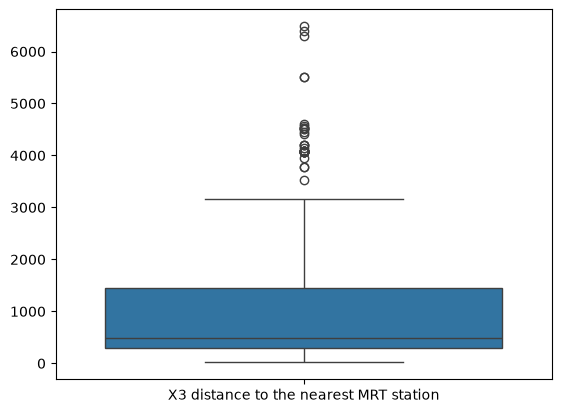

In [7]:
# df = df.drop(columns = ['No', 'X1 transaction date'])
# df
sns.boxplot(df[['X3 distance to the nearest MRT station']]) # < 3100

<Axes: >

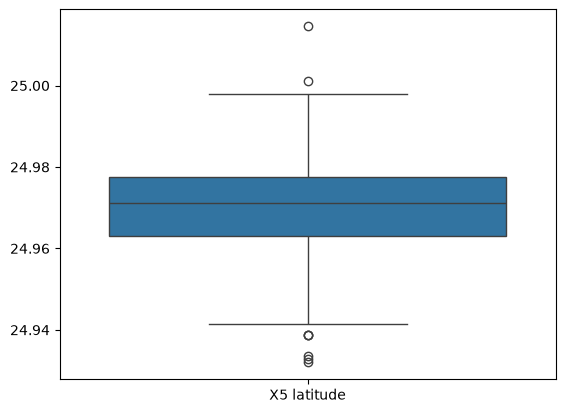

In [8]:
sns.boxplot(df[['X5 latitude']]) #  > 24 and less than 25

<Axes: >

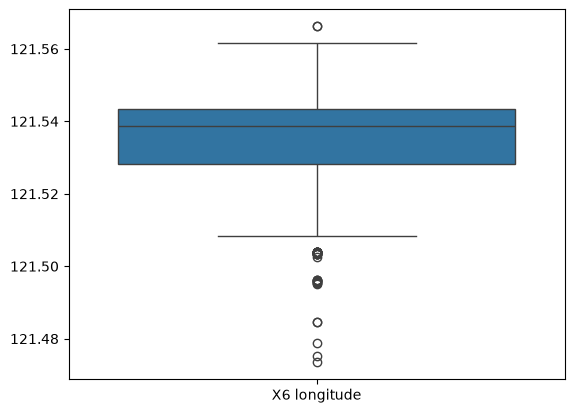

In [9]:
sns.boxplot(df[['X6 longitude']]) # > 121.50

## Using IQR to clean data

In [10]:
# Q1 -> 0.25
# Q2 -> 0.50
# Q3 -> 0.75

# Value under q1 -> Lower Bound
# Value over q3 -> Upper Bound

### df['X3 distance to the nearest MRT station']

In [ ]:
q1 = df['X3 distance to the nearest MRT station'].quantile(0.25)
q3 = df['X3 distance to the nearest MRT station'].quantile(0.75)

np.float64(591.7149)

In [ ]:
iqr = q3 - q1

np.float64(357.98294999999996)

In [13]:
distance_lower_bound = q1 - (1.5 * iqr)
distance_upper_bound = q3 + (1.5 * iqr)

In [14]:
# df = df[df['X3 distance to the nearest MRT station'].between(distance_lower_bound, distance_upper_bound)]
df = df[(df['X3 distance to the nearest MRT station'] >= distance_lower_bound) & 
        (df['X3 distance to the nearest MRT station'] <= distance_upper_bound)]

### df[['X5 latitude']]

In [50]:
q1 = df['X5 latitude'].quantile(0.25)
q3 = df['X5 latitude'].quantile(0.75)

lat_iqr = q3 - q1

lat_lower_bound = q1 - (1.5 * lat_iqr)
lat_upper_bound = q3 + (1.5 * lat_iqr)

In [52]:
df = df[(df['X5 latitude'] >= lat_lower_bound) & (df['X5 latitude'] <= lat_upper_bound)]

### ['X6 longitude']

In [17]:
q1 = df['X6 longitude'].quantile(0.25)
q3 = df['X6 longitude'].quantile(0.75)

lon_iqr = q3 - q1

lon_lower_bound = q1 - (1.5 * lon_iqr)
lon_upper_bound = q3 + (1.5 * lon_iqr)

In [18]:
df = df[(df['X6 longitude'] >= lon_lower_bound) & (df['X6 longitude'] <= lon_upper_bound)]

In [19]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
406,407,2013.167,1.9,372.13860,7,24.97293,121.54026,40.5
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [20]:
# sns.boxplot(df[['X3 distance to the nearest MRT station']]) # < 3100
# sns.boxplot(df[['X5 latitude']]) #  > 24 and less than 25
# sns.boxplot(df[['X6 longitude']]) # > 121.50

# IQR / Z-Score

In [21]:
# filter_data = df[
#     (df['X3 distance to the nearest MRT station'] < 3100)
#     & (df['X5 latitude'].between(24, 25))
#     & (df['X6 longitude'] > 121.50)
# ]
# filter_data.columns

## Feature and Target

In [ ]:
features = ['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [55]:
X = df[features]
Y = df[target]

## Train Test Split

In [56]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [58]:
Y_test

269    23.0
44     53.9
209    40.9
101    32.9
121    48.0
       ... 
381    47.3
237    39.0
350    42.3
220    78.3
389    67.7
Name: Y house price of unit area, Length: 63, dtype: float64

## Feature Scaling

In [26]:
'''
-> (Xi - mean)/sd
- fit_transform(X_train) -> [fit -> learning (mean & sd) / transform -> implement]
- transform(X_test) -> [transform -> implement]
'''

'\n-> (Xi - mean)/sd\n- fit_transform(X_train) -> [fit -> learning (mean & sd) / transform -> implement]\n- transform(X_test) -> [transform -> implement]\n'

In [27]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Define Model

In [28]:
model = LinearRegression()

In [29]:
# Fit learning data to model.
model.fit(X_train_scale, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-3.55,-4.94, 1.03, 3.25, 0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,42.39
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[20.86,17.52,15.74,13.82, 8.91]"


In [30]:
# testing test records
Y_pred = model.predict(X_test_scale)

## Metrics

In [31]:
beta_0 = model.intercept_
beta_1 = model.coef_

In [32]:
print(f'Intercept: {beta_0}')
print(f'Slope: {beta_1}')

Intercept: 42.38888888888955
Slope: [-3.54903269 -4.93596231  1.02653205  3.24807193  0.1193727 ]


In [33]:
# metrics(Y_test (actual data), Y_pred (model predicted data))
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

In [59]:
print(f'Mean Absolute Error: {mae:,.2f}')
print(f'Mean Squared Error: {mse:,.2f}')
print(f'Root Mean Squared Error: {rmse:,.2f}')
print(f'Residual Score: {r2:,.2f}')

Mean Absolute Error: 6.20
Mean Squared Error: 76.88
Root Mean Squared Error: 8.77
Residual Score: 0.53


## Visualization

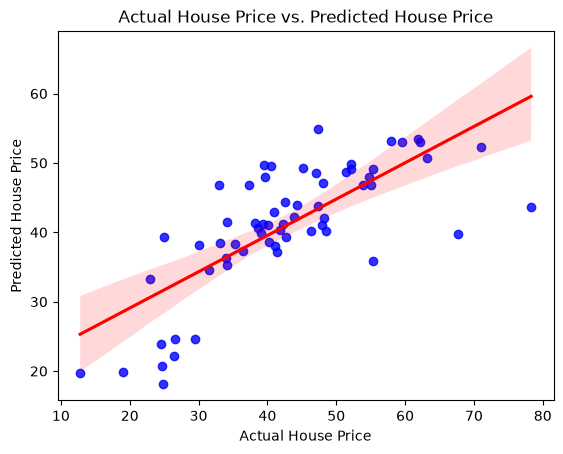

In [53]:
sns.regplot(x=Y_test, y=Y_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual House Price vs. Predicted House Price')
plt.show()

## Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

In [37]:
rf_model = RandomForestRegressor()

In [38]:
rf_model.fit(X_train_scale, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [39]:
rf_pred = rf_model.predict(X_test_scale)

In [40]:
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(Y_test, rf_pred)

In [41]:
print(f'RF Mean Absolute Error: {rf_mae}')
print(f'RF Mean Squared Error: {rf_mse}')
print(f'RF Root Mean Squared Error: {rf_rmse}')
print(f'RF Residual Score: {rf_r2}')

RF Mean Absolute Error: 5.418660317460319
RF Mean Squared Error: 59.99865892734335
RF Root Mean Squared Error: 7.745880126063361
RF Residual Score: 0.6342319074950901


<Axes: xlabel='Y house price of unit area'>

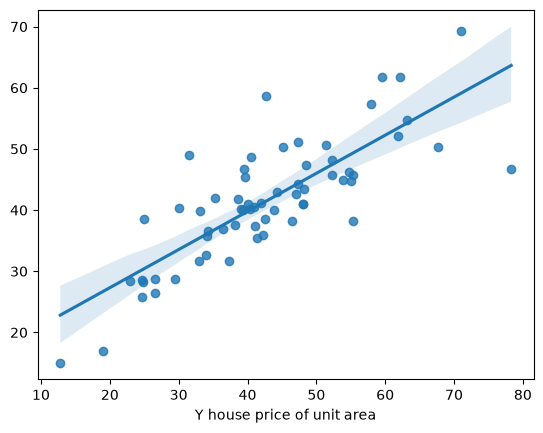

In [42]:
sns.regplot(x=Y_test, y=rf_pred)

In [43]:
'''
Types of Regression Model Evaluation
-------------------------------------
1. Cross Validation (Universal)
    - Mostly used for small or medium size datasets (<= 100000)
    - Model will learn train data 5 to 6 times.
    
2. Polynomial Regression
    - If our feature contains any non-linear pattern.
    - Handles non linear pattern.

3. Ridge Regression
    - Converts high weight features to 0 or close to zero
    
4. Lasso Regression
    - Removes high weight features
    
5. Elastic Net
    - Hybrid Regression -> Combination of Ridge Regression and Lasso Regression
'''

'\nTypes of Regression Model Evaluation\n-------------------------------------\n1. Cross Validation (Universal)\n    - Mostly used for small or medium size datasets (<= 100000)\n    - Model will learn train data 5 to 6 times.\n\n2. Polynomial Regression\n    - If our feature contains any non-linear pattern.\n    - Handles non linear pattern.\n\n3. Ridge Regression\n    - Converts high weight features to 0 or close to zero\n\n4. Lasso Regression\n    - Removes high weight features\n\n5. Elastic Net\n    - Hybrid Regression -> Combination of Ridge Regression and Lasso Regression\n'

In [44]:
'''
Pearson Correlation -> Which only calculates linear pattern.
Spearsman correlation -> Which only calculates and finds non-linear pattern.
'''

'\nPearson Correlation -> Which only calculates linear pattern.\nSpearsman correlation -> Which only calculates and finds non-linear pattern.\n'

In [45]:
# corrleation heatmap
corr_data = df.corr(method='spearman')
# corr_data

<Axes: >

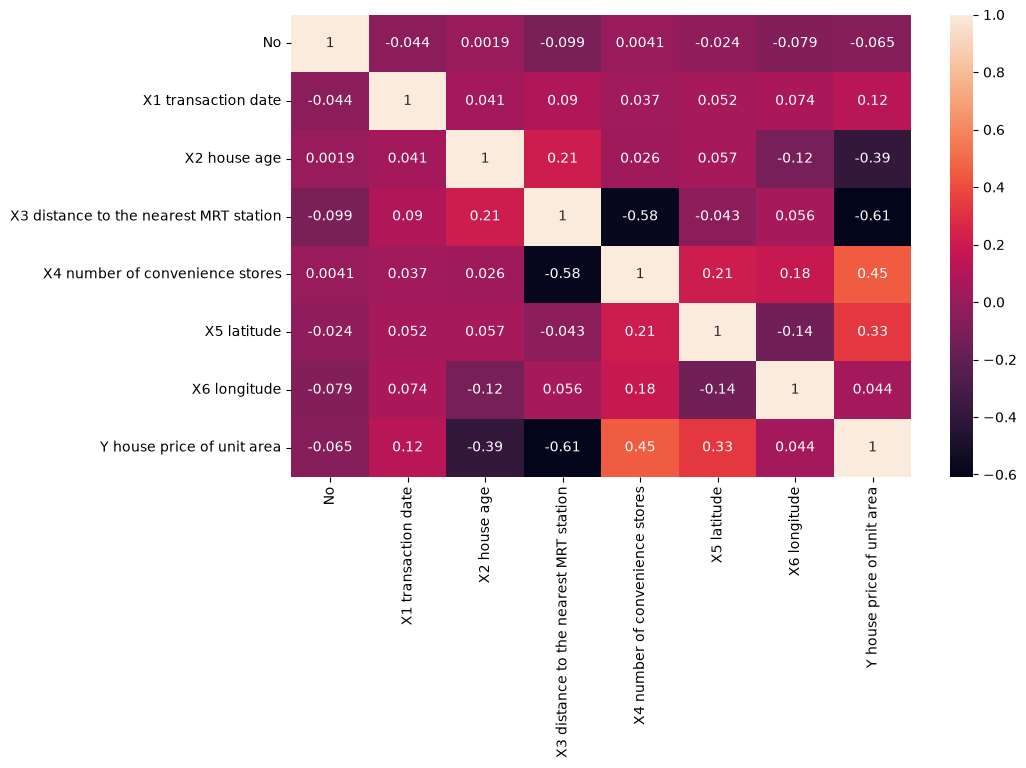

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_data, annot=True)

In [ ]:
kff=